In [ ]:
#构建NiN块
import torch
from torch import nn
from d2l import torch as d2l

def nin_block(in_channels,out_channels,kernel_size,strides,padding):
    return nn.Sequential(
        nn.Conv2d(in_channels,out_channels,kernel_size,strides,padding),
        nn.ReLU(),nn.Conv2d(out_channels,out_channels,kernel_size=1),
        nn.ReLU(),nn.Conv2d(out_channels,out_channels,kernel_size=1),
        nn.ReLU()
    )

In [ ]:
#NiN模型
net=nn.Sequential(
    #第一个nin块
    nin_block(1,96,kernel_size=11,strides=4,padding=0),
    nn.MaxPool2d(kernel_size=3,stride=2),
    #第二个nin块
    nin_block(96,256,kernel_size=5,strides=1,padding=2),
    nn.MaxPool2d(kernel_size=3,stride=2),
    #第三个nin块
    nin_block(256,384,kernel_size=3,strides=1,padding=1),
    nn.MaxPool2d(kernel_size=3,stride=2),nn.Dropout(0.5),
    #第四个nin块,标签类别是10
    nin_block(384,10,kernel_size=3,strides=1,padding=1),
    #全局平均池化层
    nn.AdaptiveAvgPool2d((1,1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten()
)

In [ ]:
#观察输出层形状
X=torch.rand(size=(1,1,224,224))
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape\t',X.shape)

In [ ]:
batch_size=128
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size=batch_size,resize=224)

In [ ]:
#模型训练
def evaluate_accuracy_gpu(net,data_iter,device=None):
    if isinstance(net,torch.nn.Module):
        net.eval()
        if not device:
            device=next(iter(net.parameters())).device
    metric=d2l.Accumulator(2)
    for X,y in data_iter:
        if isinstance(X,list):
            X=[x.to(device) for x in X]
        else:
            X=X.to(device)
        y=y.to(device)
        metric.add(d2l.accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]

In [ ]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    def init_weight(m):
        if type(m)==nn.Linear or type(m)==nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weight)
    print('training on:',device)
    net.to(device)
    optimizer=torch.optim.AdamW(net.parameters(),lr=lr)
    loss=nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)

    #训练循环
    for epoch in range(num_epochs):
        metric=d2l.Accumulator(3)
        net.train()
        for i,(X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X,y=X.to(device),y.to(device)
            y_hat=net(X)
            l=loss(y_hat,y)
            l.backward()
            optimizer.step()
            metric.add(l.item()*X.shape[0],d2l.accuracy(y_hat,y),X.shape[0])
            timer.stop()
            train_l=metric[0]/metric[2]
            train_acc=metric[1]/metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc=evaluate_accuracy_gpu(net,test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
        print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
        print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.230, train acc 0.916, test acc 0.907
1664.9 examples/sec on cuda:0


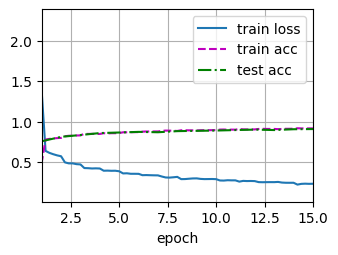

In [11]:
#模型评估与调参
lr,num_epochs=0.001,15
train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())